**Task 2: Quantitative analysis using pynance and TaLib**

Objective: Load historical stock price data, compute financial technical indicators, and
visualize the results to understand market behavior.


In [6]:
%load_ext autoreload
%autoreload 2
import sys
import os

# 1. Tell the notebook where to find your 'src' folder
sys.path.append(os.path.abspath('../'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


1. Prepare Your Data


In [ ]:
# Import your custom modules
from src.data_loader import load_stock_data, process_financial_data

# Define file path
nvda_path = "../data/raw/NVDA.csv"

# Load raw dataset
print("Loading raw data for NVDA...")
raw_nvda = load_stock_data(nvda_path)

# Clean dataset
print("Applying financial cleaning rules...")
clean_nvda = process_financial_data(raw_nvda)


# Check data types
print(clean_nvda.dtypes)

# Missing values
print("Missing Values Remaining")
print(clean_nvda.isnull().sum())

# Preview dataset
print("Preview of the Clean NVDA Dataset")
print(clean_nvda.head())

Loading raw data for NVDA...
Applying financial cleaning rules...
Cleaned data saved successfully.
Date      datetime64[us, UTC]
Close                 float64
High                  float64
Low                   float64
Open                  float64
Volume                  int64
dtype: object
Missing Values Remaining
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Preview of the Clean NVDA Dataset
                       Date     Close      High       Low      Open  \
0 2009-01-02 00:00:00+00:00  0.199652  0.201027  0.184294  0.184982   
1 2009-01-05 00:00:00+00:00  0.203319  0.207904  0.195984  0.197360   
2 2009-01-06 00:00:00+00:00  0.210196  0.216156  0.204695  0.209279   
3 2009-01-07 00:00:00+00:00  0.197589  0.205382  0.190483  0.205382   
4 2009-01-08 00:00:00+00:00  0.192546  0.195067  0.180626  0.195067   

       Volume  
0   497124000  
1   705736000  
2   657904000  
3   870096000  
4  1014496000  


**2. Compute Technical Indicators with TA-Lib**

In [14]:
from src.indicators import add_moving_averages, add_rsi, add_macd, add_financial_metrics

print("Computing technical indicators for NVDA...")

# Apply the mathematical transformations sequentially
clean_nvda = add_moving_averages(clean_nvda)
clean_nvda = add_rsi(clean_nvda)
clean_nvda = add_macd(clean_nvda)

# Apply the financial metrics (This creates the 'Daily_Return' column!)
clean_nvda = add_financial_metrics(clean_nvda)

print(" Indicators computed successfully! Previewing results:")
clean_nvda[
    [
        'Date', 
        'Close', 
        'SMA_20', 
        'RSI', 
        'MACD', 
        'Daily_Return'
    ]
].tail()

2026-05-10 09:20:20,234 - WARNING - PyNance calculation skipped: module 'pynance' has no attribute 'tech'


Computing technical indicators for NVDA...
 Indicators computed successfully! Previewing results:


,Date,Close,SMA_20,RSI,MACD,Daily_Return
3769,2023-12-22 00:00:00+00:00,48.805527,47.706983,55.352119,0.634352,-0.003266
3770,2023-12-26 00:00:00+00:00,49.254299,47.759019,57.245971,0.655689,0.009195
3771,2023-12-27 00:00:00+00:00,49.392231,47.838989,57.837928,0.675937,0.002800
3772,2023-12-28 00:00:00+00:00,49.497185,47.908266,58.310919,0.692470,0.002125
3773,2023-12-29 00:00:00+00:00,49.497185,48.046003,58.310919,0.697532,0.000000


**Apply PyNance for Financial Metrics**

In [16]:
from src.financial_metrics import add_financial_metrics

clean_nvda = add_financial_metrics(clean_nvda)

# Pass the analyzed_nvda dataframe you generated in the previous step
clean_nvda = add_financial_metrics(clean_nvda)
print("Metrics computed successfully!")
clean_nvda[['Date', 'Returns', 'Volatility_20', 'Cumulative_Return']].tail()

Metrics computed successfully!


,Date,Returns,Volatility_20,Cumulative_Return
3769,2023-12-22 00:00:00+00:00,-0.003266,0.018823,244.453217
3770,2023-12-26 00:00:00+00:00,0.009195,0.018810,246.700993
3771,2023-12-27 00:00:00+00:00,0.002800,0.018665,247.391855
3772,2023-12-28 00:00:00+00:00,0.002125,0.018630,247.917539
3773,2023-12-29 00:00:00+00:00,0.000000,0.017250,247.917539


**Visualize the Data**


Generating Price & Moving Averages Chart...


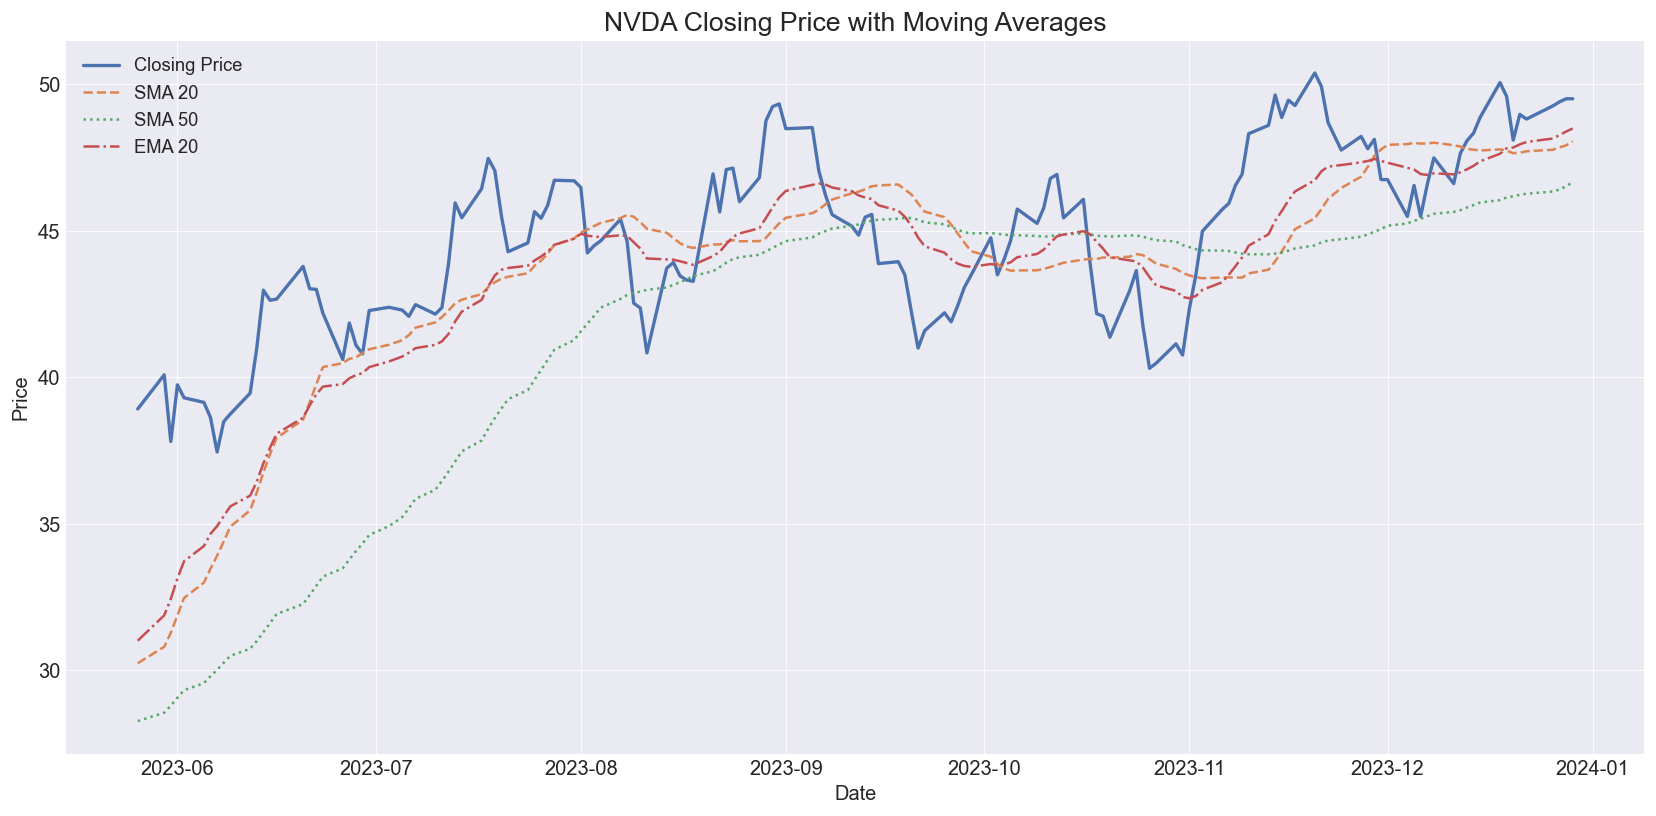

In [17]:
from src.visuals import set_visual_style, plot_price_and_ma, plot_rsi, plot_macd

# Apply the global darkgrid style
set_visual_style()

symbol = 'NVDA'

# 1. Plot Price and Moving Averages
print("Generating Price & Moving Averages Chart...")
plot_price_and_ma(clean_nvda, symbol)

Generating RSI Chart...


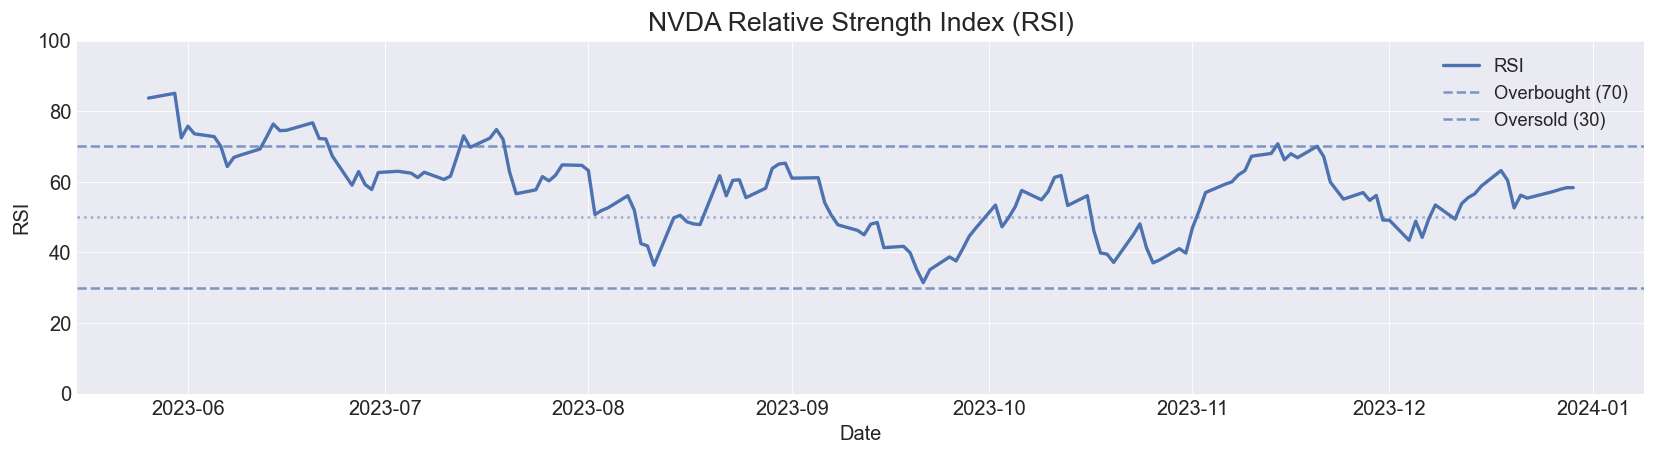

In [18]:
# 2. Plot Relative Strength Index
print("Generating RSI Chart...")
plot_rsi(clean_nvda, symbol)

Generating MACD Chart...


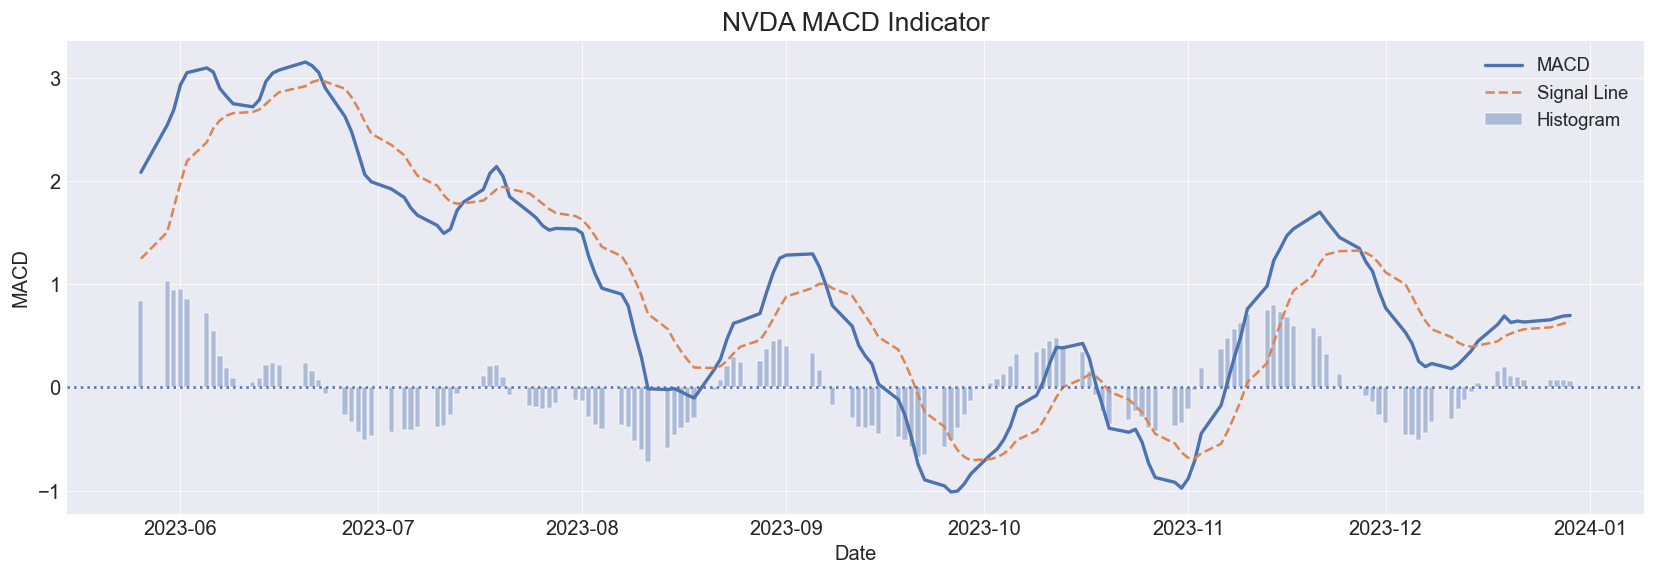

In [19]:
# 3. Plot MACD
print("Generating MACD Chart...")
plot_macd(clean_nvda, symbol)

In [20]:
# save the processed dataset for task 3
import os

# Ensure the directory exists
os.makedirs("../data/processed", exist_ok=True)

# Save the finalized dataset
processed_nvda_path = f"../data/processed/{symbol}_processed.csv"
clean_nvda.to_csv(processed_nvda_path, index=False)

print(f" {symbol} quantitative analysis complete and saved to {processed_nvda_path}")

 NVDA quantitative analysis complete and saved to ../data/processed/NVDA_processed.csv
